In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt 
from data_processing.processing.figure_of_merit import fit_fom, FOM, gaussian, n_sigma_classifier,  bimodal
from data_processing.reporting.plotting import plot_fom, plot_scatter, plot_classification_with_grouping
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from scipy.stats import linregress
from scipy.signal import savgol_filter

In [2]:
PARQ_ROOT = Path("../sample_datasets/AmBe FOM/caen_psd_SDataF_AmBe_for_FOM_analysis.2.parquet")
# SIG_ROOT = Path("C:/Users/User/Desktop/FOM Analysis/Sig")
# PARQ_PATHS = [path for path in PARQ_ROOT.iterdir()]
# SIG_PATHS = [path for path in SIG_ROOT.iterdir()]

In [3]:
psd_report = pd.read_parquet(PARQ_ROOT)
psd_report["tail / total"] = (psd_report["ENERGY"] - psd_report["ENERGYSHORT"]) / psd_report["ENERGY"]
psd_report = psd_report.dropna()

In [4]:
psd_report

,BOARD,CHANNEL,TIMETAG,ENERGY,CALIB_ENERGY,ENERGYSHORT,FLAGS,PROBE_CODE,tail / total
0,0,0,631953315,177,0.126635,149,0x4000,1,0.158192
1,0,0,1154183612,251,0.178465,217,0x4000,1,0.135458
2,0,0,1649983280,150,0.107724,127,0x4000,1,0.153333
3,0,0,1668707080,187,0.133639,157,0x4000,1,0.160428
4,0,0,1941178461,447,0.315743,386,0x4000,1,0.136465
...,...,...,...,...,...,...,...,...,...
61951,0,0,24849149200138,136,0.097919,106,0x4000,1,0.220588
61952,0,0,24849167582164,165,0.118230,136,0x4000,1,0.175758
61953,0,0,24849489723345,164,0.117530,132,0x4000,1,0.195122
61954,0,0,24850073885221,585,0.412398,503,0x4000,1,0.140171


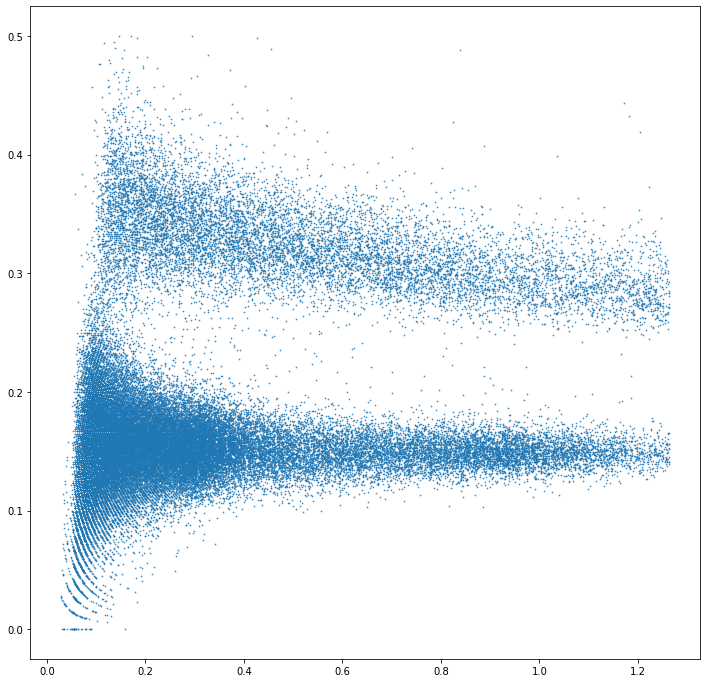

In [5]:
fig, ax = plt.subplots(figsize=(12,12))

psd_report = psd_report[psd_report["tail / total"].between(0,0.5)]

ax.scatter(
    psd_report["CALIB_ENERGY"], psd_report["tail / total"], s=0.5, alpha=0.8
)

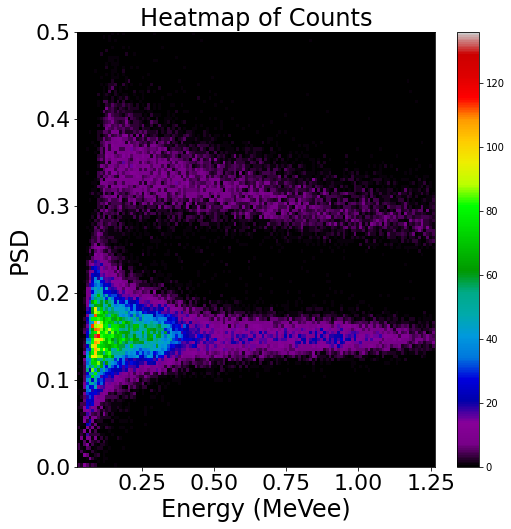

In [6]:
# generating psd/energy 2D histogram
resolution = int(1024/8)

x, y = psd_report["CALIB_ENERGY"], psd_report["tail / total"]
Z, xe, ye = np.histogram2d(x, y, resolution)

fig, ax = plt.subplots(figsize=(8,8))
cmap = plt.colormaps["nipy_spectral"]
pcm = ax.pcolormesh(xe, ye, Z.T, cmap=cmap)

fontsize = 24
# ax.set_xlim(xe[0],1)
ax.set_title("Heatmap of Counts", fontsize=fontsize)
ax.set_ylabel("PSD", fontsize=fontsize)
ax.set_xlabel("Energy (MeVee)", fontsize=fontsize)
ax.tick_params(axis='both', which='major', labelsize=22)
ax.tick_params(axis='both', which='minor', labelsize=22)
fig.colorbar(pcm, ax=ax)

In [42]:
# slice width
f"Energy Slice Width = {xe[2] - xe[1]:.4f} MeVee"

'Energy Slice Width = 0.0097 MeVee'

Text(0.5, 0, 'Counts')

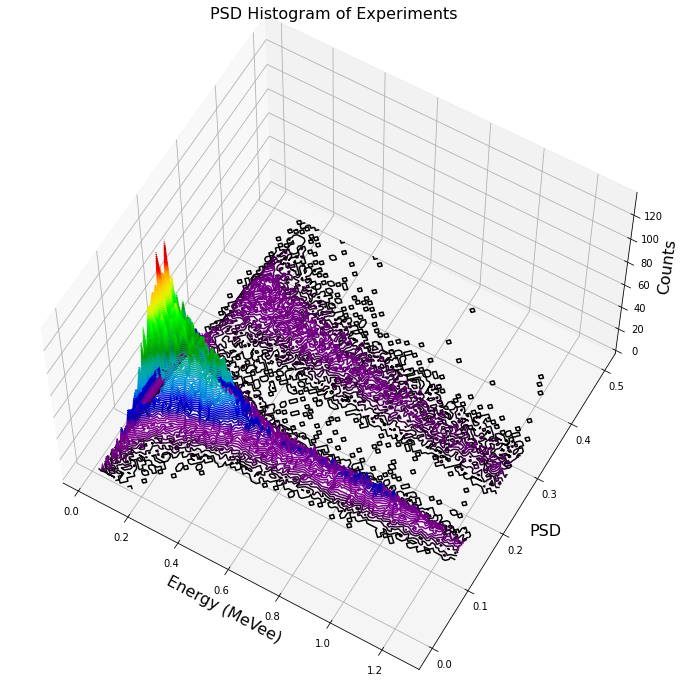

In [8]:
# histogram contour plot (vaporwave island)
contour_res = 100
angle_elev = 60
angle_rot = -60

fig = plt.figure(figsize=(12,12))
ax = plt.axes(projection='3d')

x, y = np.meshgrid(xe[:-1], ye[:-1])

ax.view_init(angle_elev, angle_rot)
ax.contour3D(x, y, Z.T, contour_res, cmap=cmap)
ax.set_title("PSD Histogram of Experiments", fontsize=16)
ax.set_ylabel("PSD", fontsize=16)
ax.set_xlabel("Energy (MeVee)", fontsize=16)
ax.set_zlabel("Counts", fontsize=16)

In [9]:
def split_params(params):
    params = abs(params)
    return params[0:3], params[3:]

def log_bimodal(x, mu1, sigma1, a1, mu2, sigma2, a2):
    return np.log(bimodal(x, mu1, sigma1, a1, mu2, sigma2, a2))

def scan_histogram_slices(bin_lbs, histogram, bounds, start_idx, end_idx):
    # end_idx is not inclusive (like end of range())
    end_idx = min(len(histogram), end_idx)
    slice_params = []
    slice_err = []
    for i in range(start_idx, end_idx):
        params, cov = curve_fit(
        bimodal,
        bin_lbs,
        histogram[:,i],
        bounds=bounds
    )
        perr = np.sqrt(np.diag(cov))
        gamma_params, neutron_params = split_params(params)
        fom = FOM(*gamma_params[:-1], *neutron_params[:-1])
        slice_params.append((i, *params, fom))
        slice_err.append((i, *perr))

    df = pd.DataFrame(slice_params, columns=['i', 'mu1', 'sigma1', 'a1', 'mu2', 'sigma2', 'a2', 'fom'])
    err_df = pd.DataFrame(slice_err, columns=['i', 'mu1', 'sigma1', 'a1', 'mu2', 'sigma2', 'a2'])
    return df, err_df

def find_threshold_fom_slice(bin_lbs, histogram, bounds, start_idx, end_idx):
    # end_idx is not inclusive (like end of range())
    # TODO redefine in terms of scan_histogram_slices()
    end_idx = min(len(histogram), end_idx)
    for i in range(start_idx, end_idx):
        params, _ = curve_fit(
        bimodal,
        bin_lbs,
        histogram[:,i],
        bounds=bounds
    )

        gamma_params, neutron_params = split_params(params)

        fom = FOM(*gamma_params[:-1], *neutron_params[:-1])

        if round(fom, 3) >= 1.269:
            return i, params

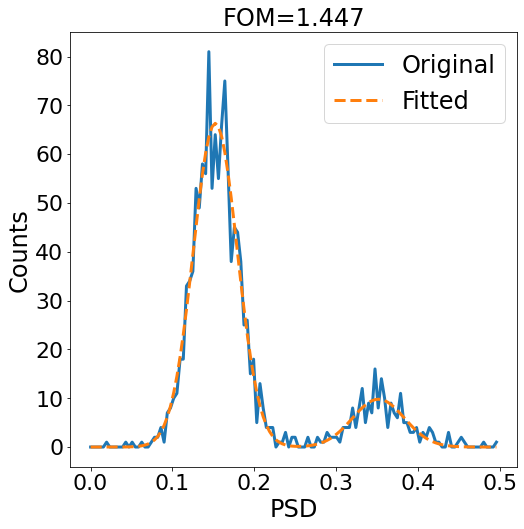

In [10]:
# looking at threshold FOM slice
psd_bin_lbs = ye[:-1]

fit_bounds = (
    (0.05, 0.001, 1, 
     0.23, 0.0001, 1),
    (0.2, 0.5, 200,
     0.4, 0.5, 50)
)


fom_idx, params = find_threshold_fom_slice(psd_bin_lbs, Z.T, fit_bounds, 5, len(xe))


histogram_slice = Z.T[:,fom_idx]

# params, _ = curve_fit(
#     bimodal,
#     psd_bin_lbs, 
#     histogram_slice,
#     bounds=fit_bounds
# )
fig, ax = plt.subplots(figsize=(8,8))
ax.plot(psd_bin_lbs, histogram_slice, lw=3, label="Original")
ax.plot(psd_bin_lbs, bimodal(psd_bin_lbs, *params), '--', lw=3, label="Fitted")

gamma_params, neutron_params = split_params(params)

ax.set_title(f"FOM={FOM(*gamma_params[:-1], *neutron_params[:-1]):.3f}", fontsize=fontsize)
ax.set_ylabel("Counts", fontsize=fontsize)
ax.set_xlabel("PSD", fontsize=fontsize)
ax.legend(fontsize=fontsize)
ax.tick_params(axis='both', which='major', labelsize=22)
ax.tick_params(axis='both', which='minor', labelsize=22)

In [11]:
# scan PSD/energy histogram
df, err_df = scan_histogram_slices(psd_bin_lbs, Z.T, fit_bounds, 0, len(Z))

In [36]:
# super-awesome histogram scan animation
%matplotlib notebook
from matplotlib.animation import FuncAnimation

fig = plt.figure(figsize=(8,8))
ax = plt.axes(xlim=(0, 0.5), ylim=(0,100))

line1, = ax.plot([], [], 'k', lw=3, label='Actual')
line2, = ax.plot([], [], 'r--', lw=3, label='Fit')

def init():
    line1.set_data([], [])
    line2.set_data([], [])
    ax.legend()
    ax.set_xlabel('PSD')
    ax.set_ylabel('N')
    return line1, line2
def animate(i):
    x = psd_bin_lbs
    y = Z.T[:,i]
    line1.set_data(x, y)
    params = tuple(df.iloc[i,1:7])
    fom = df['fom'][i]
    y = bimodal(x, *params)
    line2.set_data(x, y)
#     mu1, _, a1, mu2, _, a2 = params
#     ax.vlines([mu1, mu2], [0, 0], [a1, a2])
    ax.set_title(f"i={i}, E={xe[i]:.3f} MeVee, FOM={fom:.3f}")

    return line1, line2

anim = FuncAnimation(fig, animate, init_func=init, frames=len(psd_bin_lbs), interval=120, blit=True)
anim.save('graph.gif', writer='pillow')

<IPython.core.display.Javascript object>

In [13]:
%matplotlib inline

In [14]:
def fit_to_poly(x, y, degree):
    return np.poly1d(np.polyfit(x, y, degree))

def get_param_slice(dataframe, col_label, min, max):
    return dataframe[col_label][min:max]

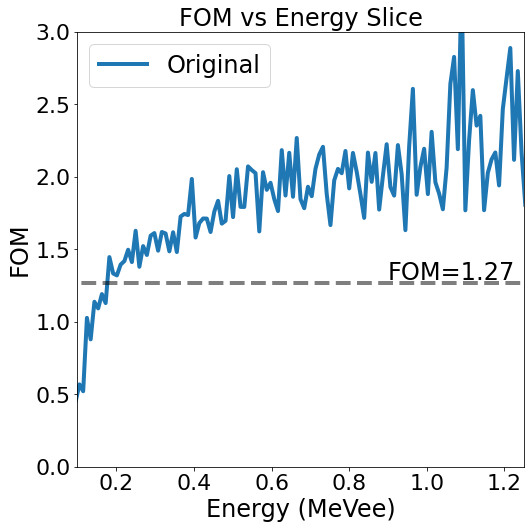

In [34]:
# index vs FOM
# fom_fit = fit_to_poly(df['fom'][2:10], xe[2:10], 3)
fom_space = np.linspace(1, 1.9, 100)

fig, ax = plt.subplots(figsize=(8,8))

ax.plot(xe[1:-1], df['fom'][1:], label="Original", lw=4)
# ax.plot(fom_fit(fom_space), fom_space, '--', label="Fitted", lw=4)
ax.hlines(1.27, 0, 1.25, color='k', linestyle='--', alpha=0.5, lw=4)
ax.text(*(0.9, 1.27 + 0.02), "FOM=1.27", fontsize=fontsize)

ax.set_ylim(0,3)
ax.set_xlim(0.1,1.25)

ax.set_title("FOM vs Energy Slice", fontsize=fontsize)
ax.set_ylabel("FOM", fontsize=fontsize)
ax.set_xlabel("Energy (MeVee)", fontsize=fontsize)

ax.legend(fontsize=fontsize)

# ax.set_yticks(np.arange(1,2.25,0.25))
ax.tick_params(axis='both', which='major', labelsize=22)
ax.tick_params(axis='both', which='minor', labelsize=22)

In [40]:
fom_fit = interp1d(df["fom"][fom_idx-1:fom_idx+1], xe[fom_idx-1:fom_idx+1], kind="linear")


L0 = fom_fit(1.27)
f"FOM ENERGY CUTOFF = {L0:.4f} MeVee"

'FOM ENERGY CUTOFF = 0.1769 MeVee'

In [20]:
# settings for window fitting
poly_degree = 4  # TODO need this?
n_window_height = 4
g_window_height = 8
max_slice_idx = 65  # TODO determine programmatically

n_window_offset = n_window_height/2
g_window_offset = g_window_height/2
min_slice_idx = fom_idx - 1

all_slice_xs = xe[:-1]
fitting_slice_xs = xe[min_slice_idx:max_slice_idx]

In [21]:
def interp(x, y):
    return interp1d(x, y, "previous", fill_value="extrapolate")

def neutron_ub_fit(x):
    return neutron_lb_fit(x) + window_offset

In [23]:
window_offset = 0.2
neutron_lb = savgol_filter(df["mu1"] + 4 * df["sigma1"], window_length=21, polyorder=3)
neutron_lb_fit = interp1d(all_slice_xs, neutron_lb, fill_value="extrapolate")

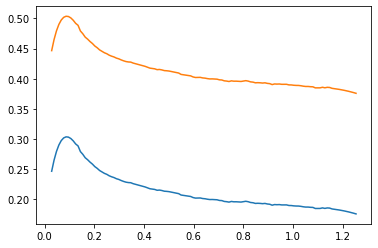

In [24]:
plt.plot(all_slice_xs, neutron_lb_fit(all_slice_xs))
plt.plot(all_slice_xs, neutron_ub_fit(all_slice_xs))

In [25]:
# window fitting
def classify(psd_report, lb_fit_fn, ub_fit_fn):
    neutron_filter = psd_report["tail / total"].between(
        lb_fit_fn(psd_report["CALIB_ENERGY"].astype(float)), ub_fit_fn(psd_report["CALIB_ENERGY"].astype(float))
    )
    neutrons = psd_report[neutron_filter]
    gammas = psd_report[~neutron_filter]
    
    return neutrons, gammas

def plot_classification(neutrons, gammas, lb_fit, ub_fit, max_energy, FOM_cutoff):
    fig, ax = plt.subplots(figsize=(10,10))
    ax.scatter(gammas["CALIB_ENERGY"], gammas["tail / total"], s=2, label="Gammas")
    ax.scatter(neutrons["CALIB_ENERGY"], neutrons["tail / total"], s=2, label="Neutrons")

    energy_space = np.linspace(xe[0], max_energy + 0.5, 100)

    ax.plot(energy_space, lb_fit(energy_space), 'r--')
    ax.plot(energy_space, ub_fit(energy_space), 'r--')
    
    ax.vlines(all_slice_xs[0], lb_fit(all_slice_xs[0]), ub_fit(all_slice_xs[0]), 'r', ls='--')
    # ax.vlines(max_energy, lb_fit(max_energy), ub_fit(max_energy), 'r', ls='--')

    ax.vlines(FOM_cutoff, lb_fit(FOM_cutoff), ub_fit(FOM_cutoff), 'k', alpha=0.5)

    ax.set_title(f"N > FOM ={neutrons[neutrons['CALIB_ENERGY'] >= FOM_cutoff].shape[0]}", fontsize=fontsize)
    ax.set_ylim(0,0.55)
    ax.set_xlim(0, max_energy + .05)
    
    ax.tick_params(axis='both', which='major', labelsize=22)
    ax.tick_params(axis='both', which='minor', labelsize=22)
    
    ax.set_xlabel("Energy (MeVee)", fontsize=fontsize)
    ax.set_ylabel("PSD", fontsize=fontsize)
    ax.legend(fontsize=fontsize)
    return fig, ax

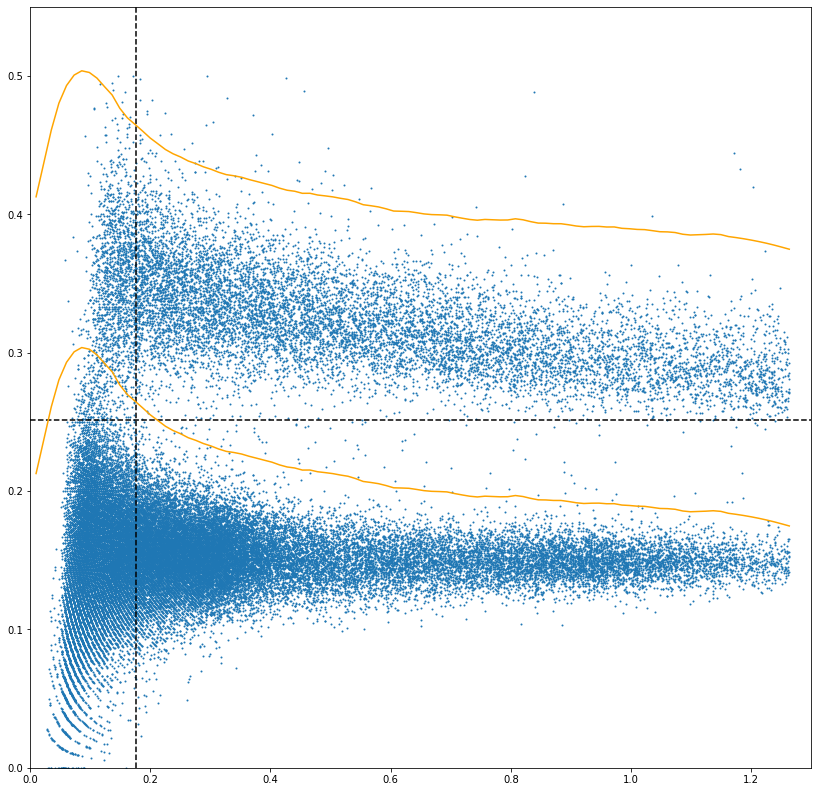

In [26]:
fig, ax = plt.subplots(figsize=(14,14))

ax.scatter(psd_report["CALIB_ENERGY"], psd_report["tail / total"], s=1)

slice_start = 15
neutron_straight_lb = df["mu2"][slice_start:] - 3 * df["sigma2"][slice_start:]
neutron_straight_lb_fit = linregress(all_slice_xs[slice_start:], neutron_straight_lb)

ax.hlines(neutron_straight_lb_fit.intercept, 0, 12, "k", ls="--")
ax.vlines(L0, 0, 1, "k", ls="--")
# ax.plot(all_slice_xs[slice_start:], neutron_lb, "k")
# ax.plot(all_slice_xs, neutron_lb_fit.slope * all_slice_xs + neutron_lb_fit.intercept, "r")

ax.set_xlim(0, 1.3)
ax.set_ylim(0, 0.55)


energy_space = np.linspace(0.01, psd_report["CALIB_ENERGY"].max(), 100)
ax.plot(energy_space, neutron_ub_fit(energy_space), "orange")
ax.plot(energy_space, neutron_lb_fit(energy_space), "orange")

# ax.plot(all_slice_xs, df["mu1"] + 4 * df["sigma1"], "orange")
# ax.plot(all_slice_xs, 0.2 +df["mu1"] + 4 * df["sigma1"], "orange")

In [27]:
neutron_sigma_classified, gamma_sigma_classified = classify(psd_report, neutron_lb_fit, neutron_ub_fit)

(<Figure size 720x720 with 1 Axes>,
 <AxesSubplot:title={'center':'N > FOM =10076'}, xlabel='Energy (MeVee)', ylabel='PSD'>)

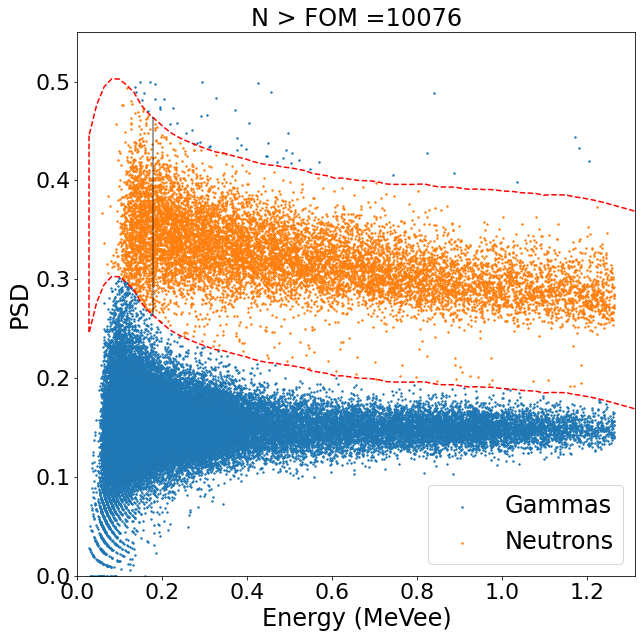

In [28]:
plot_classification(neutron_sigma_classified, gamma_sigma_classified, neutron_lb_fit, neutron_ub_fit, psd_report["CALIB_ENERGY"].max(), L0)

In [29]:
def straight_lb(x):
    return neutron_straight_lb_fit.intercept

def straight_ub(x):
    return 0.5

neutron_straight_classified, gamma_straight_classified = classify(psd_report, straight_lb, straight_ub)

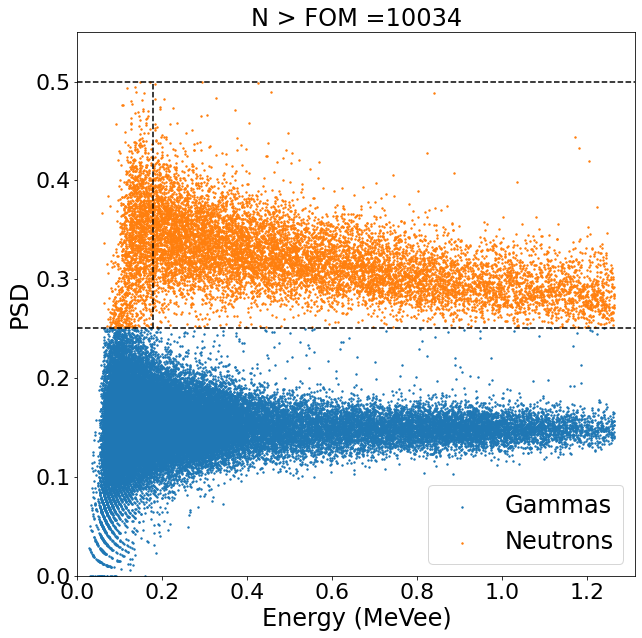

In [30]:
fig, ax = plt.subplots(figsize=(10,10))
ax.scatter(gamma_straight_classified["CALIB_ENERGY"], gamma_straight_classified["tail / total"], s=2, label="Gammas")
ax.scatter(neutron_straight_classified["CALIB_ENERGY"], neutron_straight_classified["tail / total"], s=2, label="Neutrons")

energy_space = np.linspace(xe[0], psd_report["CALIB_ENERGY"].max(), 100)

ax.hlines(neutron_straight_lb_fit.intercept, 0, 12, "k", ls="--")
ax.hlines(0.5, 0, 12, "k", ls="--")

ax.vlines(L0, neutron_straight_lb_fit.intercept, 0.5, 'k', ls='--')
# ax.vlines(psd_report["CALIB_ENERGY"].max(), neutron_straight_lb_fit.intercept, 0.5, 'k', ls='--')

ax.set_title(f"N > FOM ={neutron_straight_classified[neutron_straight_classified['CALIB_ENERGY'] >= L0].shape[0]}", fontsize=fontsize)
ax.set_ylim(0,0.55)
ax.set_xlim(0, psd_report["CALIB_ENERGY"].max() + .05)

ax.tick_params(axis='both', which='major', labelsize=22)
ax.tick_params(axis='both', which='minor', labelsize=22)

ax.set_xlabel("Energy (MeVee)", fontsize=fontsize)
ax.set_ylabel("PSD", fontsize=fontsize)
ax.legend(fontsize=fontsize)

In [31]:
# neutrons, gammas = classify(psd_report)
# fig, ax = plot_classification(neutrons, gammas)

In [32]:
10034/10076

0.9958316792377928